# Analyzing Black Carbon Column Mass Density over Minneapolis in 2025

### Timing

Exercise: 5 minutes

### Overview



### Prerequisites

This notebook was written using Python 3.10, and requires:
- Valid [Earthdata Login credentials](https://urs.earthdata.nasa.gov)
- [NumPy](https://numpy.org/)
- [Pandas](https://pandas.pydata.org/)
- [Matplotlib](https://matplotlib.org/)

You can run this tutorial in your browser using Colab:<br>

<a target="_blank" href="https://colab.research.google.com/github/nasa/gesdisc-tutorials/blob/main/webinars/March_18_2026_GMU_Webinar.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


### *Prerequisite Step for Google Colab*: Install Packages and Import Libraries

Since the `earthaccess` library is not installed by default in Google Colab, we will need to install it each time we connect to a new runtime.

In [ ]:
! pip install earthaccess

## 1. Import Libraries

In [2]:
import earthaccess
import requests
import io
import pandas
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Store Parameters

These variables will be used to query one year of hourly Black Carbon mass at 45N,93W, which will query the grid closest to Minneapolis.

A JSON of supported variables can be queried [here](https://api.giovanni.earthdata.nasa.gov/configured-variables/).

In [3]:
lat = 45
lon = -93
time_start = "2025-01-01T00:00:00"
time_end = "2025-12-31T23:00:00"
data = "M2T1NXAER_5_12_4_BCCMASS"

## 3. Retrieve Token

In this tutorial, we will call `earthaccess.login()` which will prompt for an Earthdata Login username and password if a `.netrc` file is not already stored, before finding and retrieving our Earthdata Login token.

To create a `.netrc` file manually, please use this guide: [How to Generate Earthdata Prerequisite Files](https://disc.gsfc.nasa.gov/information/howto?keywords=prerequisite&title=How%20to%20Generate%20Earthdata%20Prerequisite%20Files).

In [ ]:
auth = earthaccess.login()
token = earthaccess.get_edl_token()['access_token']

## 4. Define a Function That Calls the Time Series Service

In [5]:
time_series_url = "https://api.giovanni.earthdata.nasa.gov/timeseries"

def call_time_series(lat,lon,time_start,time_end,data):
    """
    INPUTS:
    lat - latitude
    lon - longitude
    time_start - start of time series in YYYY-MM-DDThh:mm:ss format (UTC)
    end_time - end of the time series in YYYY-MM-DDThh:mm:ss format (UTC)
    data - name of the data parameter for the time series

    OUTPUT:
    time series csv output string
    """
    query_parameters = {
        "data":data,
        "location":"[{},{}]".format(lat,lon),
        "time":"{}/{}".format(time_start,time_end)
    }

    headers = {
    'Authorization': f'Bearer {token}'
    }

    response=requests.get(time_series_url, params=query_parameters, headers=headers)
    return response.text


## 5. Define a Function That Parses the Response From the Time Series Service

This will return the headers from the CSV as a Python dictionary, and the values formatted as a Pandas dataframe.

In [6]:
def parse_csv(ts):
    """
    INPUTS:
    ts - time series output of the time series service

    OUTPUTS:
    headers,df - the headers from the CSV as a dict and the values in a pandas dataframe
    """
    with io.StringIO(ts) as f:
        # the first 13 rows are header
        headers = {}
        try:
            for i in range(13):
                line = f.readline()
                key,value = line.split(",",1)
                headers[key] = value.strip()
        except ValueError as e:
            raise ValueError(
                "The returned CSV is empty.\n"
                "Please ensure that your subsetting bounds are within the extent of your dataset\n"
                "or that your .netrc file is stored and contains valid credentials."
            ) from e

        # Read the csv proper
        df = pandas.read_csv(
            f,
            header=1,
            names=("Timestamp",headers["param_name"]),
            converters={"Timestamp":pandas.Timestamp}
        )

    return headers, df

## 6. Call the Time Series Service

The response will be stored in a variable called `df`.

In [7]:
%%time
ts = call_time_series(lat,lon,time_start,time_end,data)


CPU times: user 16.2 ms, sys: 1.15 ms, total: 17.4 ms
Wall time: 12.9 s


## 7. Parse the output

In [8]:
headers,df = parse_csv(ts)
print(df.head())

            Timestamp  Black Carbon Column Mass Density, time average
0 2025-01-01 00:30:00                                    5.692070e-07
1 2025-01-01 01:30:00                                    5.432460e-07
2 2025-01-01 02:30:00                                    5.040570e-07
3 2025-01-01 03:30:00                                    4.631160e-07
4 2025-01-01 04:30:00                                    4.360430e-07


## 8. Plot Results

Text(0.5, 1.0, 'M2T1NXAER_5_12_4_BCCMASS at [45.0,-93.125]')

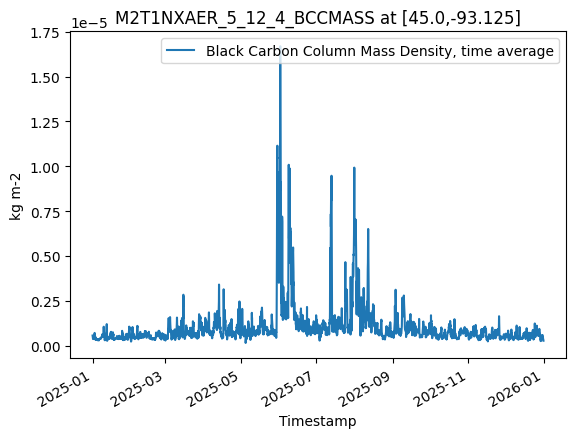

In [9]:
ax = plt.gca()
df.plot(x="Timestamp",y=headers["param_name"],ax=ax)
ax.set_ylabel(headers["unit"])
ax.set_title("{} at [{},{}]".format(data,headers["lat"],headers["lon"]))

### 9. How strong was this event?

In [10]:
df['Black Carbon Column Mass Density, time average'].describe()

,"Black Carbon Column Mass Density, time average"
count,8.759000e+03
mean,1.041946e-06
std,1.203527e-06
min,1.563720e-07
25%,5.228930e-07
50%,7.337150e-07
75%,1.043220e-06
max,1.669450e-05


In [11]:
df['Black Carbon Column Mass Density, time average'].quantile([0.90, 0.95, 0.99])

,"Black Carbon Column Mass Density, time average"
0.90,0.000002
0.95,0.000003
0.99,0.000007
